Acceleration profile calculation for Morgan Plus Four
---------------------------------------------------
Author: Meng-Ju Hsieh

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

Morgan Plus Four parameters and requirment

In [2]:
# ==================================================
# Vehicle & environment parameters
# ==================================================
Af = 1.46             # Frontal area [m^2]
Cd = 0.55             # Drag coefficient
Cr = 0.014            # Rolling resistance coefficient
m_car_net = 750       # Net vehicle mass w/o powertrain [kg]
m_batt = 250          # Battery mass [kg]
m_gear = 40           # Gearbox mass [kg]
m_driver = 75         # Driver mass [kg]
m_em = 50             # Electric motor mass [kg]
m_car = (
    m_car_net + 
    m_batt + 
    m_gear + 
    m_driver + 
    m_em
  )                  # Vehicle mass [kg]
r_wheel = 0.286      # Wheel radius [m]
k_gear = 10          # Gear ratio
rho_air = 1.225      # Air density [kg/m^3]
g = 9.81

# ==================================================
# System efficiencies
# ==================================================
eta_inv = 0.97        # Efficiency of inverter
eta_batt = 0.99       # Efficiency of battery
eta_gear= 0.97        # Efficiency of gearbox
# eta_char = 0.85       # Efficiency of charging system

# =================================================
# Tire & chassis parameters
# ==================================================
''' 
# Parameters from Red
mu_ref = 0.85          # Friction coefficient
n_load = 0.95           # Load sensitivity exponent
wheelbase = 2.52       # Wheelbase [m]
hCG = 0.40              # CG height [m]
driven_axles = 1
load_fraction = 0.50   # 50% static weight on driven axle

# Parameters for performance street EV (sticky tires or mild AWD)
mu_ref = 0.95          # Friction coefficient
n_load = 0.92           # Load sensitivity exponent
wheelbase = 2.52       # Wheelbase [m]
hCG = 0.38              # CG height [m]
driven_axles = 1
load_fraction = 0.55   # 50% static weight on driven axle
'''
# Parameters for RWD sports car
mu_ref = 0.95          # Friction coefficient: UHP summer tire
n_load = 0.92          # Load sensitivity exponent
wheelbase = 2.52       # Wheelbase [m]
hCG = 0.35             # CG height [m]
driven_axles = 1       # Number of driven axles (1 for RWD, 2 for AWD)
load_fraction = 0.55   # 55% static load on rear axle

# Effective mass (incl. rotational inertia)
m_eff = 1.006 * m_car  # ≈ given 1019.6 kg earlier

# Simulation settings
dt = 0.01
v_target = 100            # Acceleration target speed, 0 to 100 km/h
v_target = v_target / 3.6 # Convert to m/s
t_target = 5.2            # Target acceleration time [s], 0-100 km/h
v_top = 240               # Top speed in km/h
v_top = v_top / 3.6       # Convert to m/s
rpm_top = np.ceil( v_top / r_wheel * k_gear * 60 / (2*np.pi) /500 ) * 500 # Convert top speed in m/s to rpm


* Select e-machine to analyze acceleration profile:
   1. LCA_RefPMSM
   2. Inetic iEV-2U-WN200 800V/560A
   3. BMW-i3_PMSM
* Load max torque envelope (uploaded CSV files)
* Find base speed
* Curve fitting to extend max. torque envelope

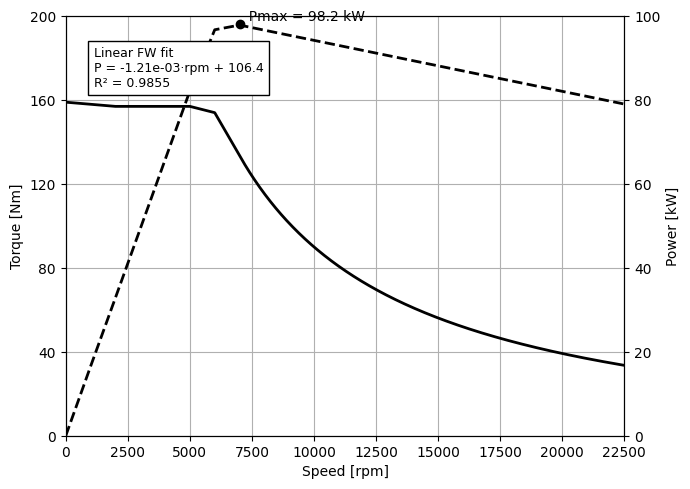

Peak Power [kW]: 98.23
Power slope [kW/rpm]: -0.00
Power intercept [kW]: 106.38
R2 power fit: 0.99


In [3]:
# Select e-machine by number
num_EM = int(float(input())-1)
EM_string = [
    "LCA_RefPMSM", 
    "iEV-2U-WN200",
    "BMW-i3_PMSM"
    ]
EM_string_tit = EM_string[num_EM].replace('_', ' ')
# Read torque envelope
csv = pd.read_csv("max_trq_envelope/" + EM_string[num_EM] + ".csv")
rpm_line = csv.iloc[:, 0].values
trq_max_curve = csv.iloc[:, 1].values

def fit_fw_linear_power_and_plot(
    rpm,
    torque,
    rpm_target,
    make_plot=True
):
    """
    Fits a linear power decay model using data from maximum power
    to maximum speed, computes R², interprets top speed,
    and optionally plots torque & power vs rpm.

    Parameters
    ----------
    rpm : array_like
        Speed data [rpm]
    torque : array_like
        Torque data [Nm]
    rpm_target : float
        Target speed [rpm]
    make_plot : bool
        If True, generates a combined torque–power plot

    Returns
    -------
    results : dict
        Dictionary containing:
        - rpm_pmax
        - p_max (kW)
        - power_slope (kW/rpm)
        - power_intercept (kW)
        - rpm_top_interpreted
        - R2_power_fit
    """

    rpm = np.asarray(rpm)
    torque = np.asarray(torque)

    # ----------------------------
    # Power calculation
    # ----------------------------
    omega = rpm * 2*np.pi / 60
    power = torque * omega / 1000  # kW

    # ----------------------------
    # 1. Base speed, maximum power & FW data
    # ----------------------------
    # Detect base speed (last flat torque point)
    tol = 2e-2
    idx_trq_mtpa = np.where(np.abs((trq_max_curve - trq_max_curve.max())/trq_max_curve.max()) < tol)[0]
    idx_base = idx_trq_mtpa[-1]
    rpm_b = rpm_line[idx_base]

    idx_pmax = np.argmax(power)

    rpm_fw = rpm[idx_pmax:]
    power_fw = power[idx_pmax:]

    rpm_pmax = rpm[idx_pmax]
    p_max = power[idx_pmax]

    # ----------------------------
    # 2. Linear power fit
    # ----------------------------
    a_fit, b_fit = np.polyfit(rpm_fw, power_fw, 1)

    power_fw_fit = a_fit * rpm_fw + b_fit

    # ----------------------------
    # R² calculation
    # ----------------------------
    ss_res = np.sum((power_fw - power_fw_fit)**2)
    ss_tot = np.sum((power_fw - np.mean(power_fw))**2)
    R2 = 1.0 - ss_res / ss_tot

    # ----------------------------
    # 3. Reconstruct envelopes
    # ----------------------------
    if rpm_target > rpm.max():
        rpm_ext = np.linspace(rpm_fw[0], rpm_target, 500)
        power_ext = a_fit * rpm_ext + b_fit
        power_ext = np.clip(power_ext, 0, None) # Ensure power doesn't go negative

        omega_ext = rpm_ext * 2*np.pi / 60
        torque_ext = power_ext * 1000 / omega_ext

        rpm_full = np.concatenate([rpm[:idx_pmax], rpm_ext])
        power_full = np.concatenate([power[:idx_pmax], power_ext])
        torque_full = np.concatenate([torque[:idx_pmax], torque_ext])
    else:
        rpm_full = rpm
        power_full = power
        torque_full = torque

    # ----------------------------
    # Plot
    # ----------------------------
    if make_plot:
        fig, ax1 = plt.subplots(figsize=(7,5))

        ax1.plot(rpm_full, torque_full, 'k', linewidth=2)
        ax1.set_xlim(0, rpm_target)
        trq_lim = (np.ceil(torque_full.max()/50))*50
        num_ticks = 6
        ax1.set_yticks(np.linspace(0, trq_lim, num_ticks))
        ax1.set_ylim(0, trq_lim)
        ax1.set_xlabel("Speed [rpm]")
        ax1.set_ylabel("Torque [Nm]")
        ax1.grid(True)

        ax2 = ax1.twinx()
        ax2.plot(rpm_full, power_full, 'k--', linewidth=2)
        pwr_lim = (np.ceil(power_full.max()/50))*50
        ax2.set_yticks(np.linspace(0, pwr_lim, num_ticks))
        ax2.set_ylim(0, pwr_lim)
        ax2.set_ylabel("Power [kW]")

        ax2.scatter(rpm_pmax, p_max, color='k', zorder=5)
        ax2.text(
            rpm_pmax, p_max,
            f"  Pmax = {p_max:.1f} kW",
            verticalalignment='bottom'
        )

        ax2.text(
            0.05 * rpm_full.max(),
            0.85 * power_full.max(),
            f"Linear FW fit\n"
            f"P = {a_fit:.2e}·rpm + {b_fit:.1f}\n"
            f"R² = {R2:.4f}",
            bbox=dict(facecolor='white', edgecolor='black'),
            fontsize=9
        )

        plt.tight_layout()
        plt.show()

    # ----------------------------
    # Results
    # ----------------------------
    return {
        "Base speed [rpm]": rpm_b,
        "Peak Power [kW]": p_max,
        "Speed at peak power [rpm]": rpm_pmax,
        "Power slope [kW/rpm]": a_fit,
        "Power intercept [kW]": b_fit,
        "R2 power fit": R2,
        "Speed line [rpm]": rpm_full,
        "Torque curve [Nm]": torque_full,
        "Power curve [kW]": power_full
    }

Dict_em_Tw = fit_fw_linear_power_and_plot(
    rpm_line,
    trq_max_curve,
    rpm_top,
    make_plot=True
)
for key, value in Dict_em_Tw.items():
    if isinstance(value, (int, float)):
        print(f"{key}: {value:.2f}")
rpm_line = Dict_em_Tw["Speed line [rpm]"]
trq_max_curve = Dict_em_Tw["Torque curve [Nm]"]
p_max_curve = Dict_em_Tw["Power curve [kW]"]

Acceleration simulation

In [4]:
def em_trq(rpm, scale=1.0):
    if rpm <= rpm_line[0]:
        return trq_max_curve[0] * scale
    elif rpm >= rpm_line[-1]:
        return 0.0
    else:
        return np.interp(rpm, rpm_line, trq_max_curve) * scale

def accel_time(grade=0.0, dt=0.01, v_target=100, a_cc=0.0, scale=1.0): 
    """
    grade = road grade (e.g. 0.06 for 6%)
    dt = simulation time step (s)
    v_target = target speed (km/h)
    a_cc = external commanded acceleration (m/s^2)
    scale = torque scaling factor (1.0 = original torque, >1.0 = increased torque)
    """
    v = 0.0
    t = 0.0
    v_target = v_target / 3.6  # Convert km/h to m/s
    Dict_temp = defaultdict(list)
    a_prev = 4
    while v < v_target:
        # Wheel & motor speed
        omega_wheel = v / r_wheel
        omega_em = omega_wheel * k_gear
        rpm_em = omega_em * 60 / (2*np.pi)

        # Available motor torque
        Tm = em_trq(rpm_em, scale=scale) * eta_gear
        T_wheel = Tm * k_gear

        # Max traction force from motor to wheel
        F_trac_max = T_wheel / r_wheel
        
        # -------------------------------------------------
        # Traction limit (with load transfer)
        # -------------------------------------------------
        # Static normal force on driven axle
        Fz_static = m_car * g * load_fraction / driven_axles

        # Longitudinal load transfer (needs acceleration estimate)
        dFz = m_car * a_prev * hCG / wheelbase
        Fz = Fz_static + dFz

        # Load‑sensitive friction
        mu_eff = mu_ref * (Fz / Fz_static)**(n_load - 1)

        F_trac_lim = mu_eff * Fz * driven_axles
        
        # Final available traction force (motor ∩ tire)
        F_trac = min(F_trac_max, F_trac_lim)
        T_trac = F_trac * r_wheel

        # Resistive forces
        F_aero = 0.5 * rho_air * Cd * Af * v**2
        F_roll = m_car * g * Cr
        F_grade = m_car * g * grade
        F_acc = m_car * a_cc
        F_load = F_aero + F_roll + F_grade + F_acc

        # Longitudinal acceleration
        if F_trac > F_load:
            a = (F_trac - F_load) / m_eff
            a = max(a, 0.0)  # do not allow backward acceleration

            a_prev = a

            # Integrate forward
            v += a * dt
            t += dt
        else:
            a = 0.0
            print("Traction limit reached. Cannot reach target speed with current torque.")
            
        Dict_temp['Time[s]'].append(t)
        Dict_temp['Max wheel torque[Nm]'].append(T_wheel)
        Dict_temp['Traction torque[Nm]'].append(T_trac)
        Dict_temp['Traction force[N]'].append(F_trac)
        Dict_temp['Road load[N]'].append(F_load)
        Dict_temp['Car speed[km/h]'].append(v * 3.6)

        if a == 0 and t > 2:
            break
    DF = pd.DataFrame(Dict_temp)
    return t, DF

Results before scaling

0–100 km/h (0% grade):  7.27 s


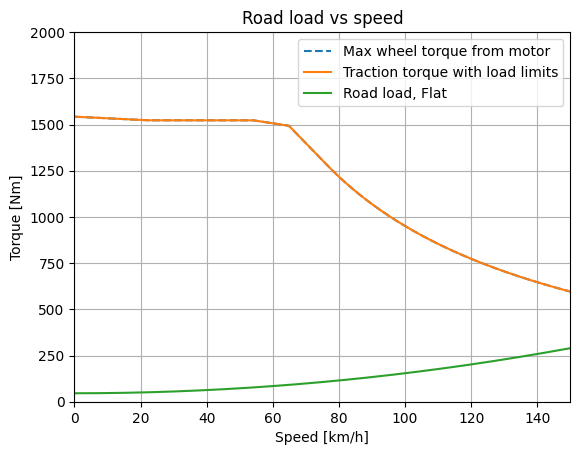

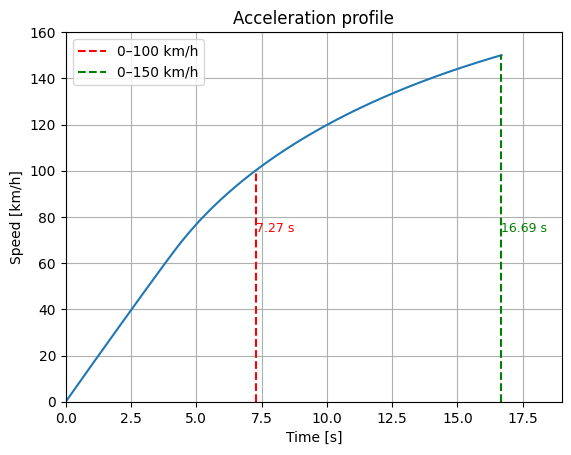

In [5]:
t_flat_100, DF_flat_100 = accel_time(grade=0.0)
t_flat_150, DF_flat_150 = accel_time(grade=0.0, v_target=150)

print(f"0–100 km/h (0% grade):  {t_flat_100:.2f} s")

plt.figure()
plt.plot(DF_flat_150['Car speed[km/h]'], DF_flat_150['Max wheel torque[Nm]'], "--", label="Max wheel torque from motor")
plt.plot(DF_flat_150['Car speed[km/h]'], DF_flat_150['Traction torque[Nm]'], label="Traction torque with load limits")
plt.plot(DF_flat_150['Car speed[km/h]'], DF_flat_150['Road load[N]'] * r_wheel, label="Road load, Flat")
plt.xlim(0, 150)
plt.ylim(0, np.ceil(DF_flat_150['Max wheel torque[Nm]'].max() * 1.1/500)*500)
plt.xlabel("Speed [km/h]")
plt.ylabel("Torque [Nm]")
plt.title("Road load vs speed")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(DF_flat_150['Time[s]'], DF_flat_150['Car speed[km/h]'])
plt.vlines(t_flat_100, 0, 100, colors='r', linestyles='--', label="0–100 km/h")
plt.vlines(t_flat_150, 0, 150, colors='g', linestyles='--', label="0–150 km/h")
plt.text(t_flat_100, 75, f"{t_flat_100:.2f} s", color='r', fontsize=9, ha='left', va='center')
plt.text(t_flat_150, 75, f"{t_flat_150:.2f} s", color='g', fontsize=9, ha='left', va='center')
plt.xlim(0, np.ceil(t_flat_150*1.1))
plt.ylim(0, 160)
plt.xlabel("Time [s]")
plt.ylabel("Speed [km/h]")
plt.title("Acceleration profile")
plt.legend()
plt.grid(True)
plt.show()

Find required torque scaling

In [6]:
scales = np.linspace(1.0, 3.0, 801)

times = []
for s in scales:
    t_sim, DF = accel_time(scale=s)
    times.append(t_sim)

times = np.array(times)

# Best achievable time (traction-limited floor)
t_best = times.min()

if t_best > t_target:
    print("Target 0–100 time NOT achievable with current traction limit")
    print(f"Best achievable time ≈ {t_best:.2f} s, with scale = {scales[times.argmin()]:.2f}")
    idx = np.where(times == t_best)[0][0]
else:
    idx = np.argmin(np.abs(times - t_target))
    print("Target reachable")
scale_best = scales[idx]
trq_max_s = trq_max_curve.max() * scale_best
    
print(f"Best torque scale = {scale_best:.2f}")
print(f"Scaled max motor torque = {trq_max_s:.1f} Nm")


Target reachable
Best torque scale = 1.58
Scaled max motor torque = 251.6 Nm


C:\Users\mjhsieh\AppData\Local\Temp\ipykernel_45884\2825716491.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


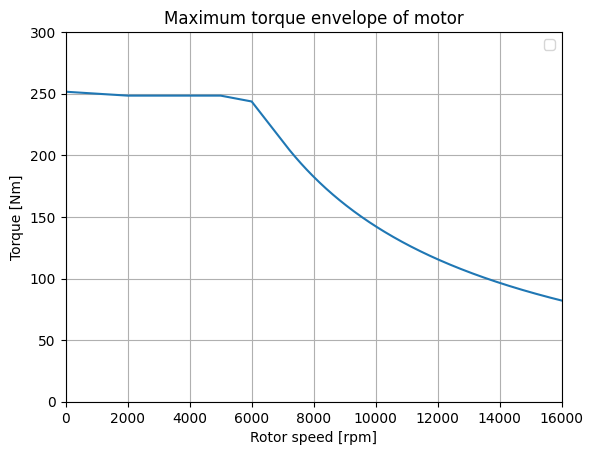

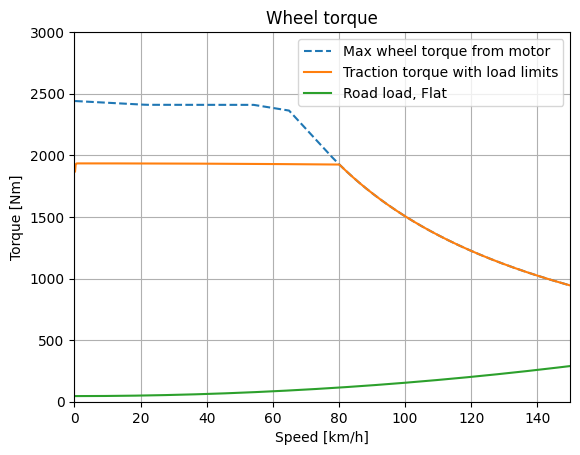

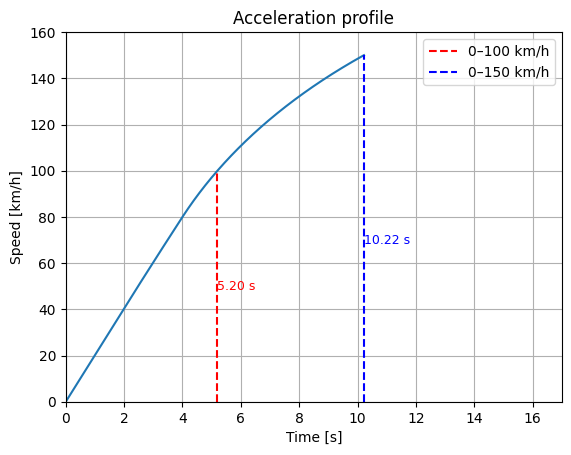

In [7]:
t_flat_100_s, DF_flat_100_s = accel_time(grade=0.0, scale=scale_best)
t_flat_150_s, DF_flat_150_s = accel_time(grade=0.0, v_target=150, scale=scale_best)

plt.figure()
plt.plot(rpm_line, trq_max_curve*scale_best)
plt.xlim(0, 16000)
plt.ylim(0, round(trq_max_s * 1.1/50)*50)
plt.xlabel("Rotor speed [rpm]")
plt.ylabel("Torque [Nm]")
plt.title("Maximum torque envelope of motor")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(DF_flat_150_s['Car speed[km/h]'], DF_flat_150_s['Max wheel torque[Nm]'], "--", label="Max wheel torque from motor")
plt.plot(DF_flat_150_s['Car speed[km/h]'], DF_flat_150_s['Traction torque[Nm]'], label="Traction torque with load limits")
plt.plot(DF_flat_150_s['Car speed[km/h]'], DF_flat_150_s['Road load[N]'] * r_wheel, label="Road load, Flat")
plt.xlim(0, 150)
plt.ylim(0, np.ceil(DF_flat_150_s['Max wheel torque[Nm]'].max() * 1.1/500)*500)
plt.xlabel("Speed [km/h]")
plt.ylabel("Torque [Nm]")
plt.title("Wheel torque")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(DF_flat_150_s['Time[s]'], DF_flat_150_s['Car speed[km/h]'])
plt.vlines(t_flat_100_s, 0, 100, colors='r', linestyles='--', label="0–100 km/h")
plt.text(t_flat_100_s, 50, f"{t_flat_100_s:.2f} s", color='r', fontsize=9, ha='left', va='center')
plt.vlines(t_flat_150_s, 0, 150, colors='b', linestyles='--', label="0–150 km/h")
plt.text(t_flat_150_s, 70, f"{t_flat_150_s:.2f} s", color='b', fontsize=9, ha='left', va='center')
plt.xlim(0, 17)
plt.ylim(0, 160)
plt.xlabel("Time [s]")
plt.ylabel("Speed [km/h]")
plt.title("Acceleration profile")
plt.legend()
plt.grid(True)
plt.show()


Chose drive cycle by its number:
1. WLTC Cl.3
2. jc08
3. FTP72 UDDS
4. NYCC
5. Artemis URBAN
6. Artemis RURAL
7. Artemis 130
8. UCLA92
9. HWFET
10. US06

Text(0.5, 1.0, 'WLTC Cl.3 - acceleration of vehicle')

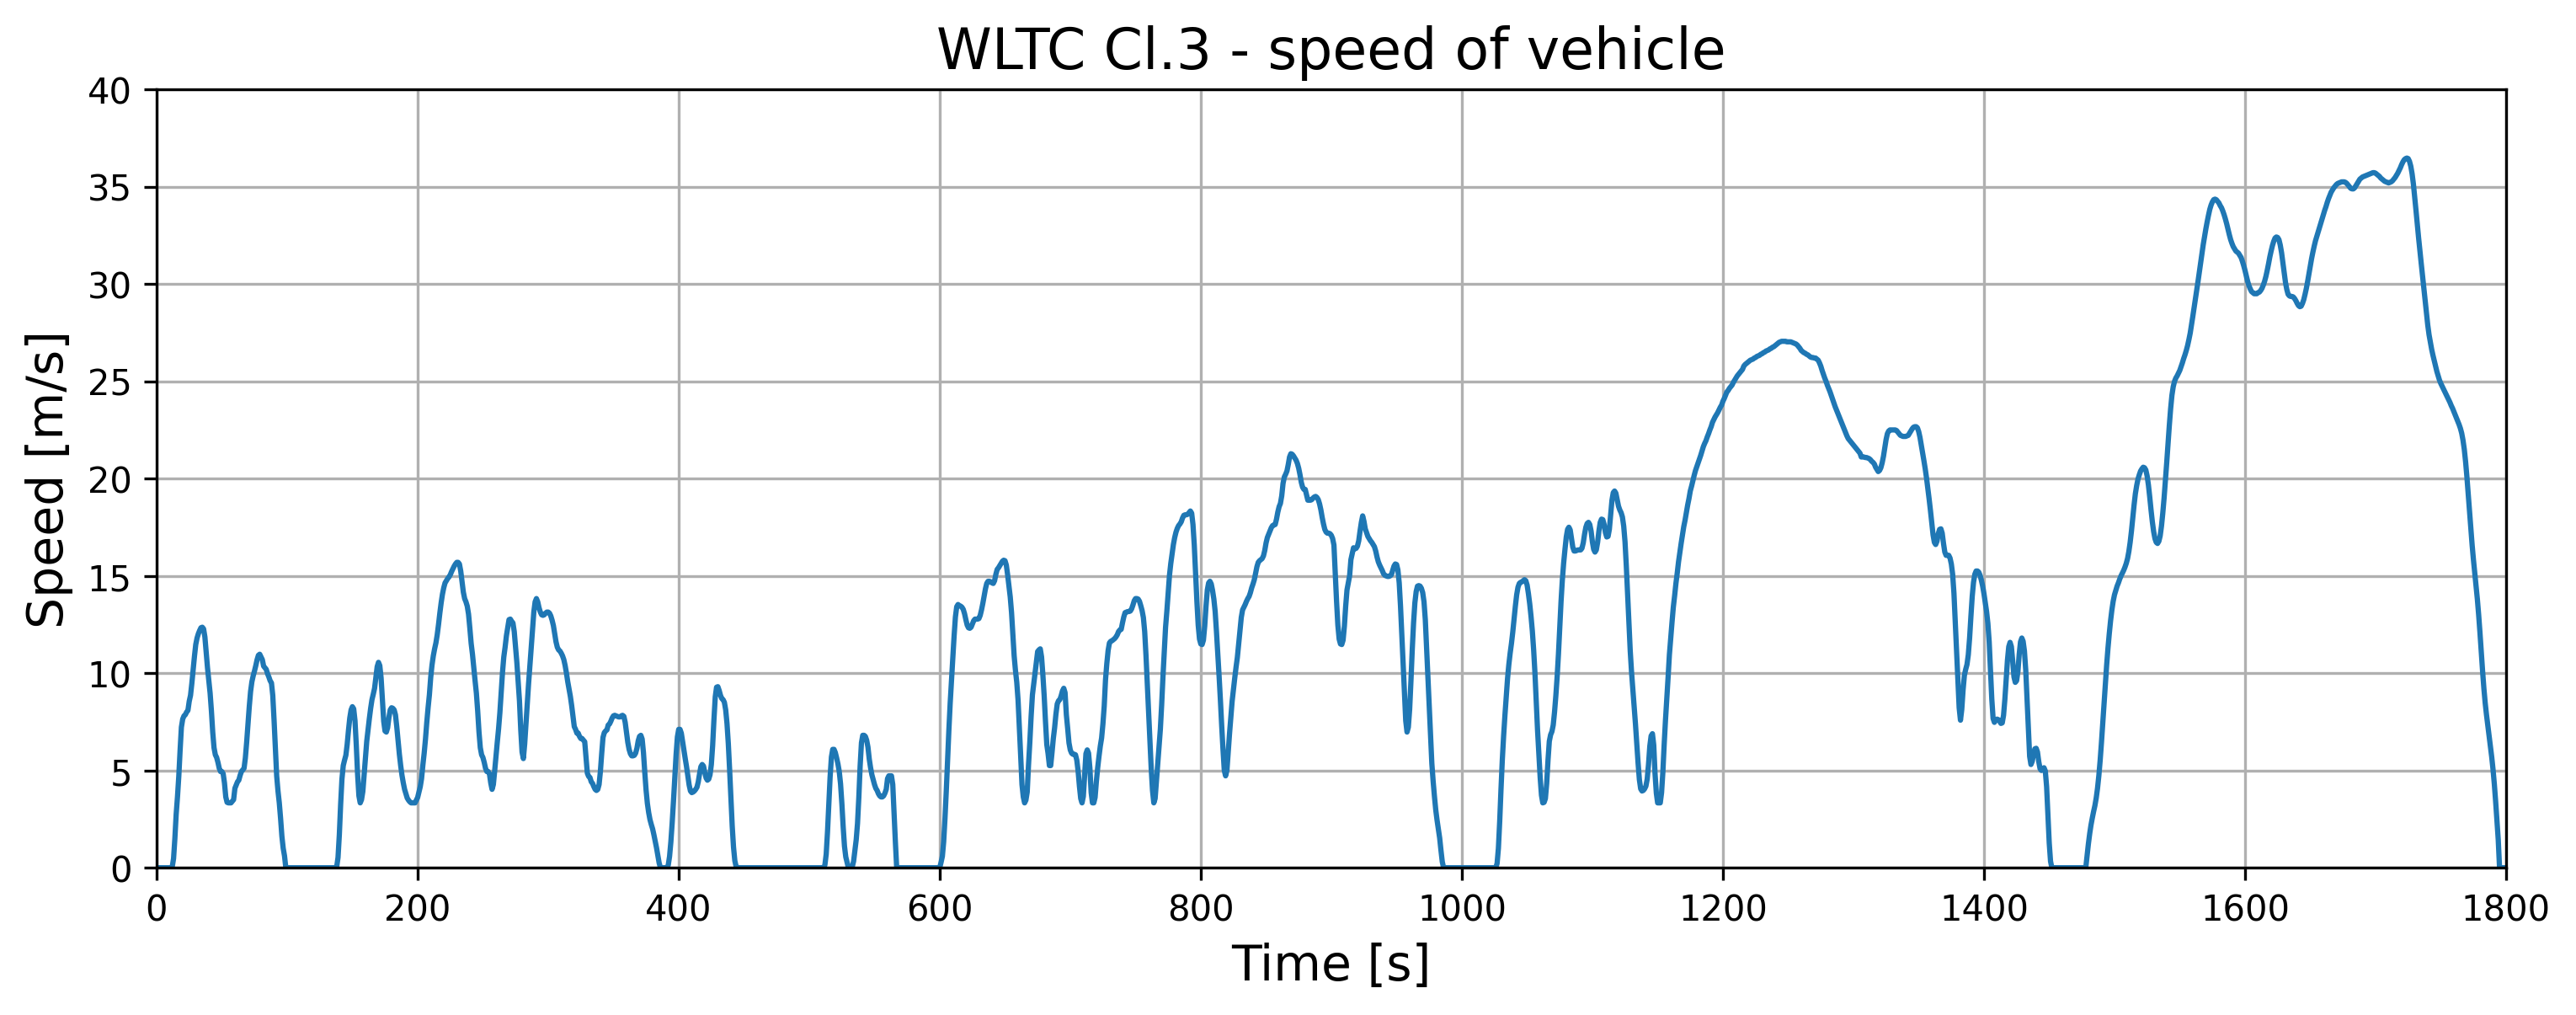

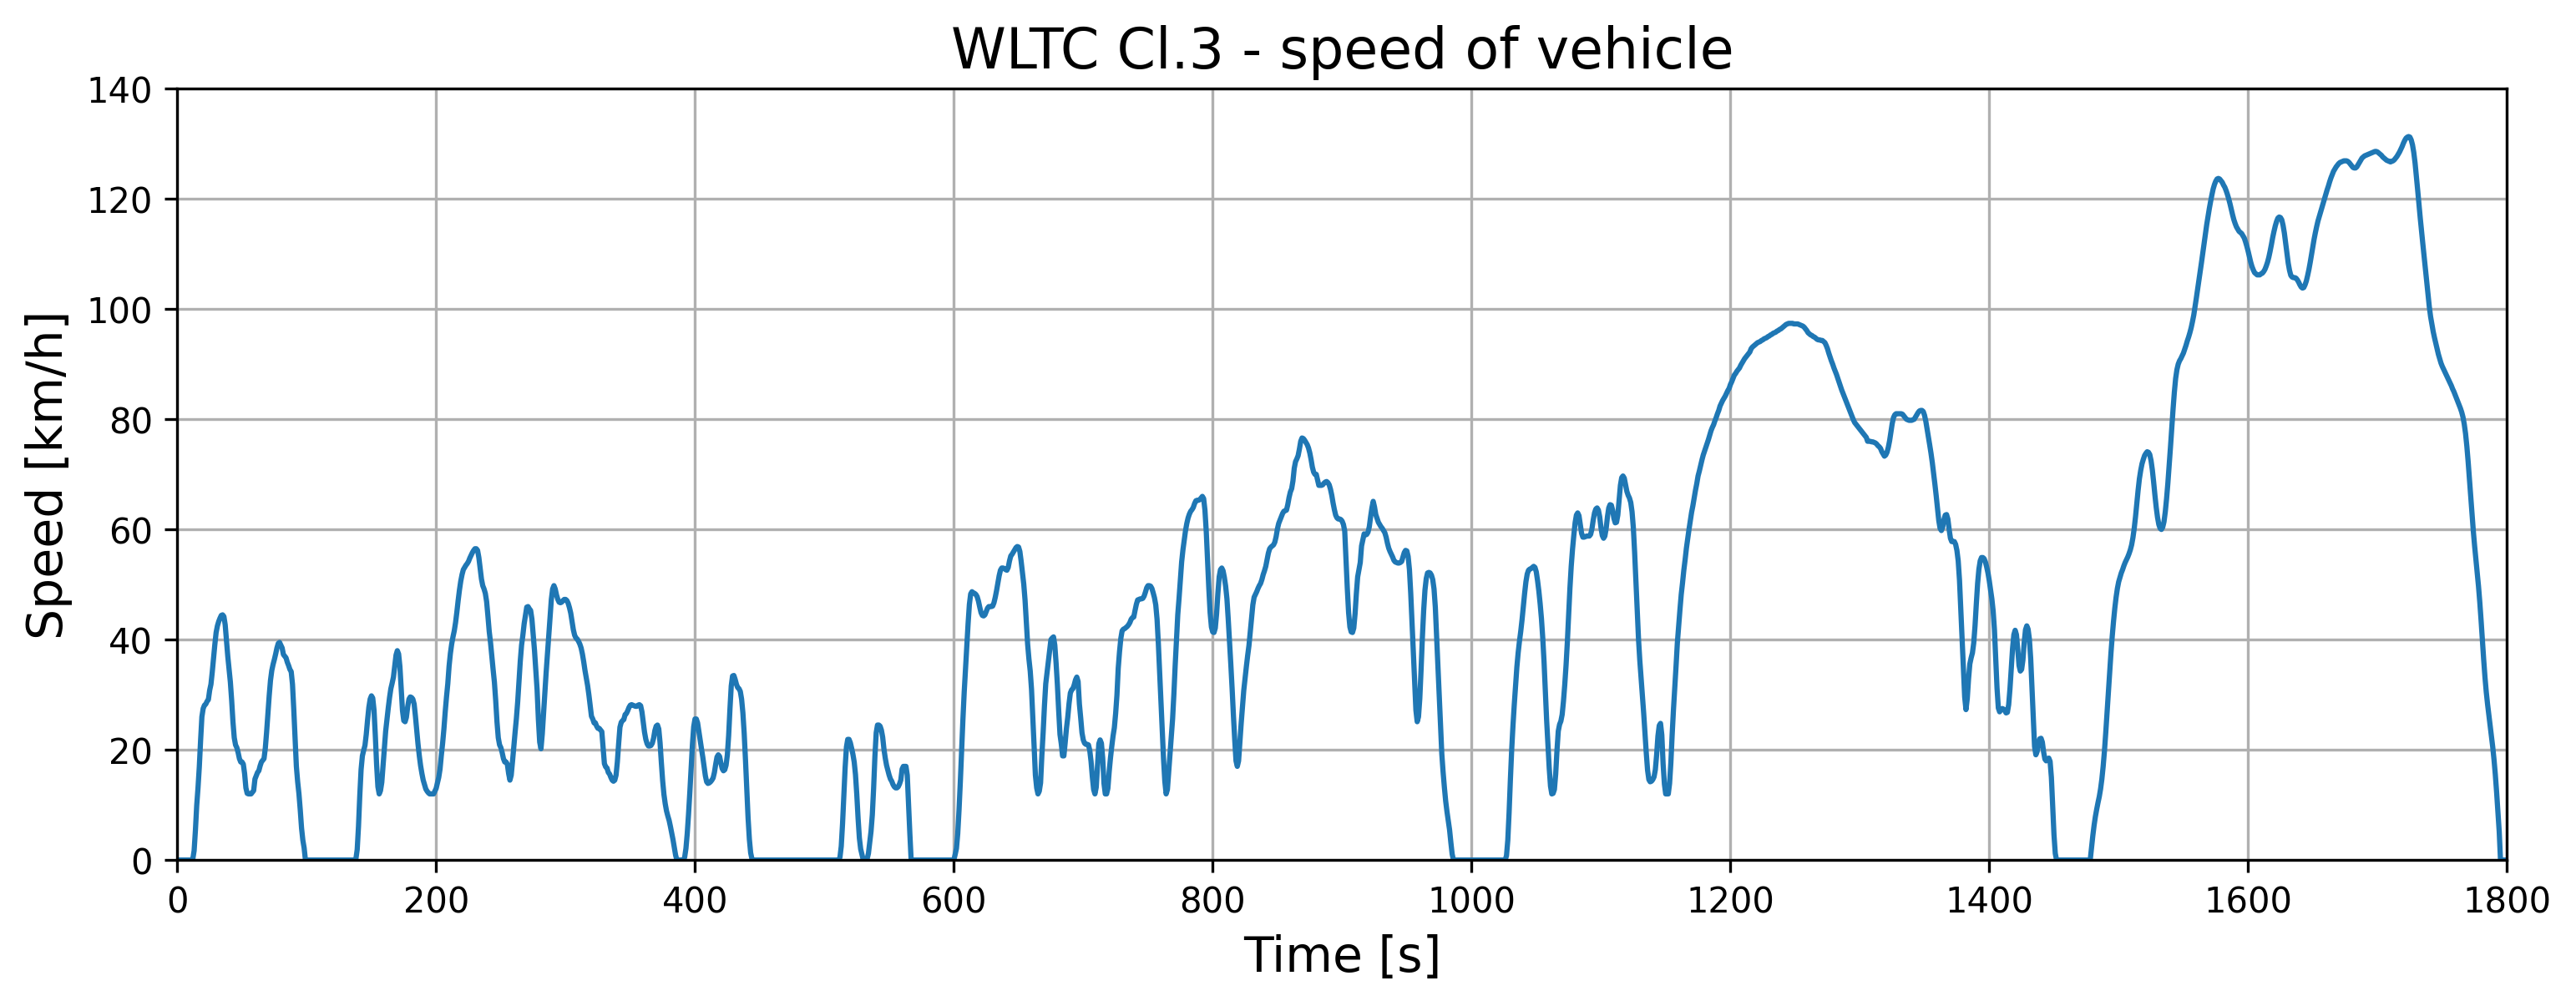

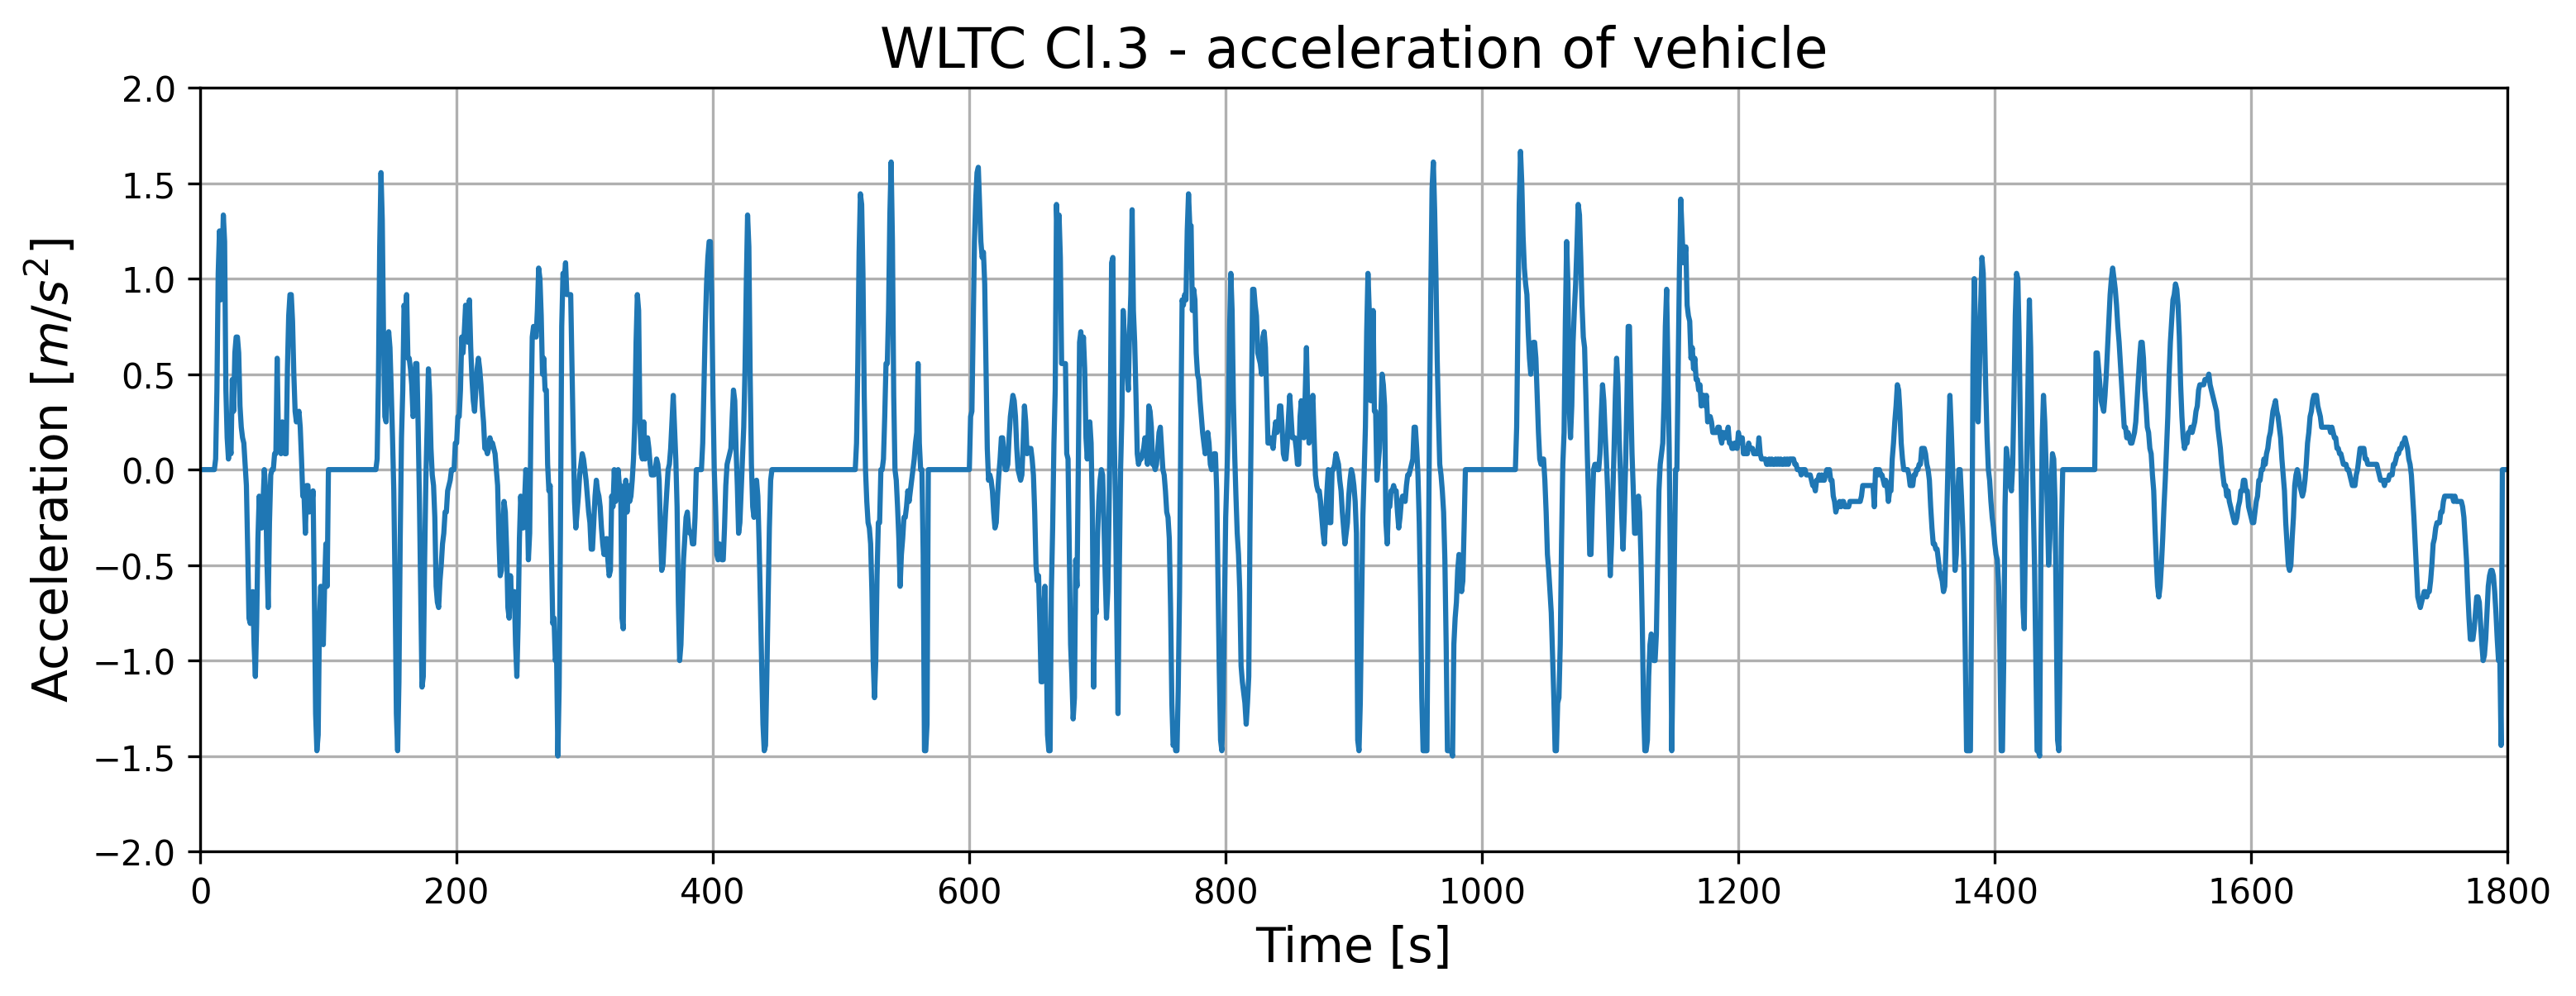

In [8]:
# %% Chozen drive cycle
Dict_DC_name = {
    "WLTC_Cl3_53": "WLTC Cl.3",
    "jpjc08": "jc08",
    "FTP72UDDS": "FTP72 UDDS",    
    "NYCC": "NYCC",
    "ArtemisURBAN": "Artemis URBAN",    
    "ArtemisRURAL": "Artemis RURAL",
    "ArtemisMW130": "Artemis 130",    
    "UCLA92": "UCLA92",
    "HWFET": "HWFET",    
    "US06": "US06",    
    }
list_DC_filename = list(Dict_DC_name.keys())
list_DC_title = list(Dict_DC_name.values())
num_DC = int(float(input())-1)
filename_DC = list_DC_filename[num_DC]
title_DC = list_DC_title[num_DC]
DF_DC = pd.read_csv("drive_cycle/" + filename_DC + ".csv")

# %% Setting for plots
size_plot = (12, 4)
dpi_plot = 300
fz_label = 14
fz_title = 16
fz_legend = 12

plt.figure(figsize=size_plot, dpi=dpi_plot)
plt.plot(DF_DC["t"], DF_DC["v"])
plt.xlim( 0, max(DF_DC["t"]) )
plt.ylim( 0, np.ceil(max(DF_DC["v"])/5)*5 )
plt.grid()
plt.xlabel("Time [s]", fontsize=fz_label)
plt.ylabel("Speed [m/s]", fontsize=fz_label)
plt.title(title_DC+" - speed of vehicle", fontsize=fz_title)

plt.figure( figsize=size_plot, dpi=dpi_plot )
plt.plot( DF_DC["t"], 3.6 * DF_DC["v"] )
plt.xlim( 0, max(DF_DC["t"]) )
plt.ylim( 0, np.ceil(max(3.6*DF_DC["v"])/20)*20 )
plt.grid()
plt.xlabel( "Time [s]", fontsize=fz_label )
plt.ylabel( "Speed [km/h]", fontsize=fz_label )
plt.title( title_DC+" - speed of vehicle", fontsize=fz_title )

plt.figure( figsize=size_plot, dpi=dpi_plot )
plt.plot( DF_DC["t"], DF_DC["a"] )
plt.xlim( 0, max(DF_DC["t"]) )
plt.ylim( np.floor(min(DF_DC["a"])), np.ceil(max(DF_DC["a"])) )
plt.grid()
plt.xlabel( "Time [s]", fontsize=fz_label )
plt.ylabel( "Acceleration [$m/s^2$]", fontsize=fz_label )
plt.title( title_DC+" - acceleration of vehicle", fontsize=fz_title )

Text(0.5, 1.0, 'WLTC Cl.3 - power')

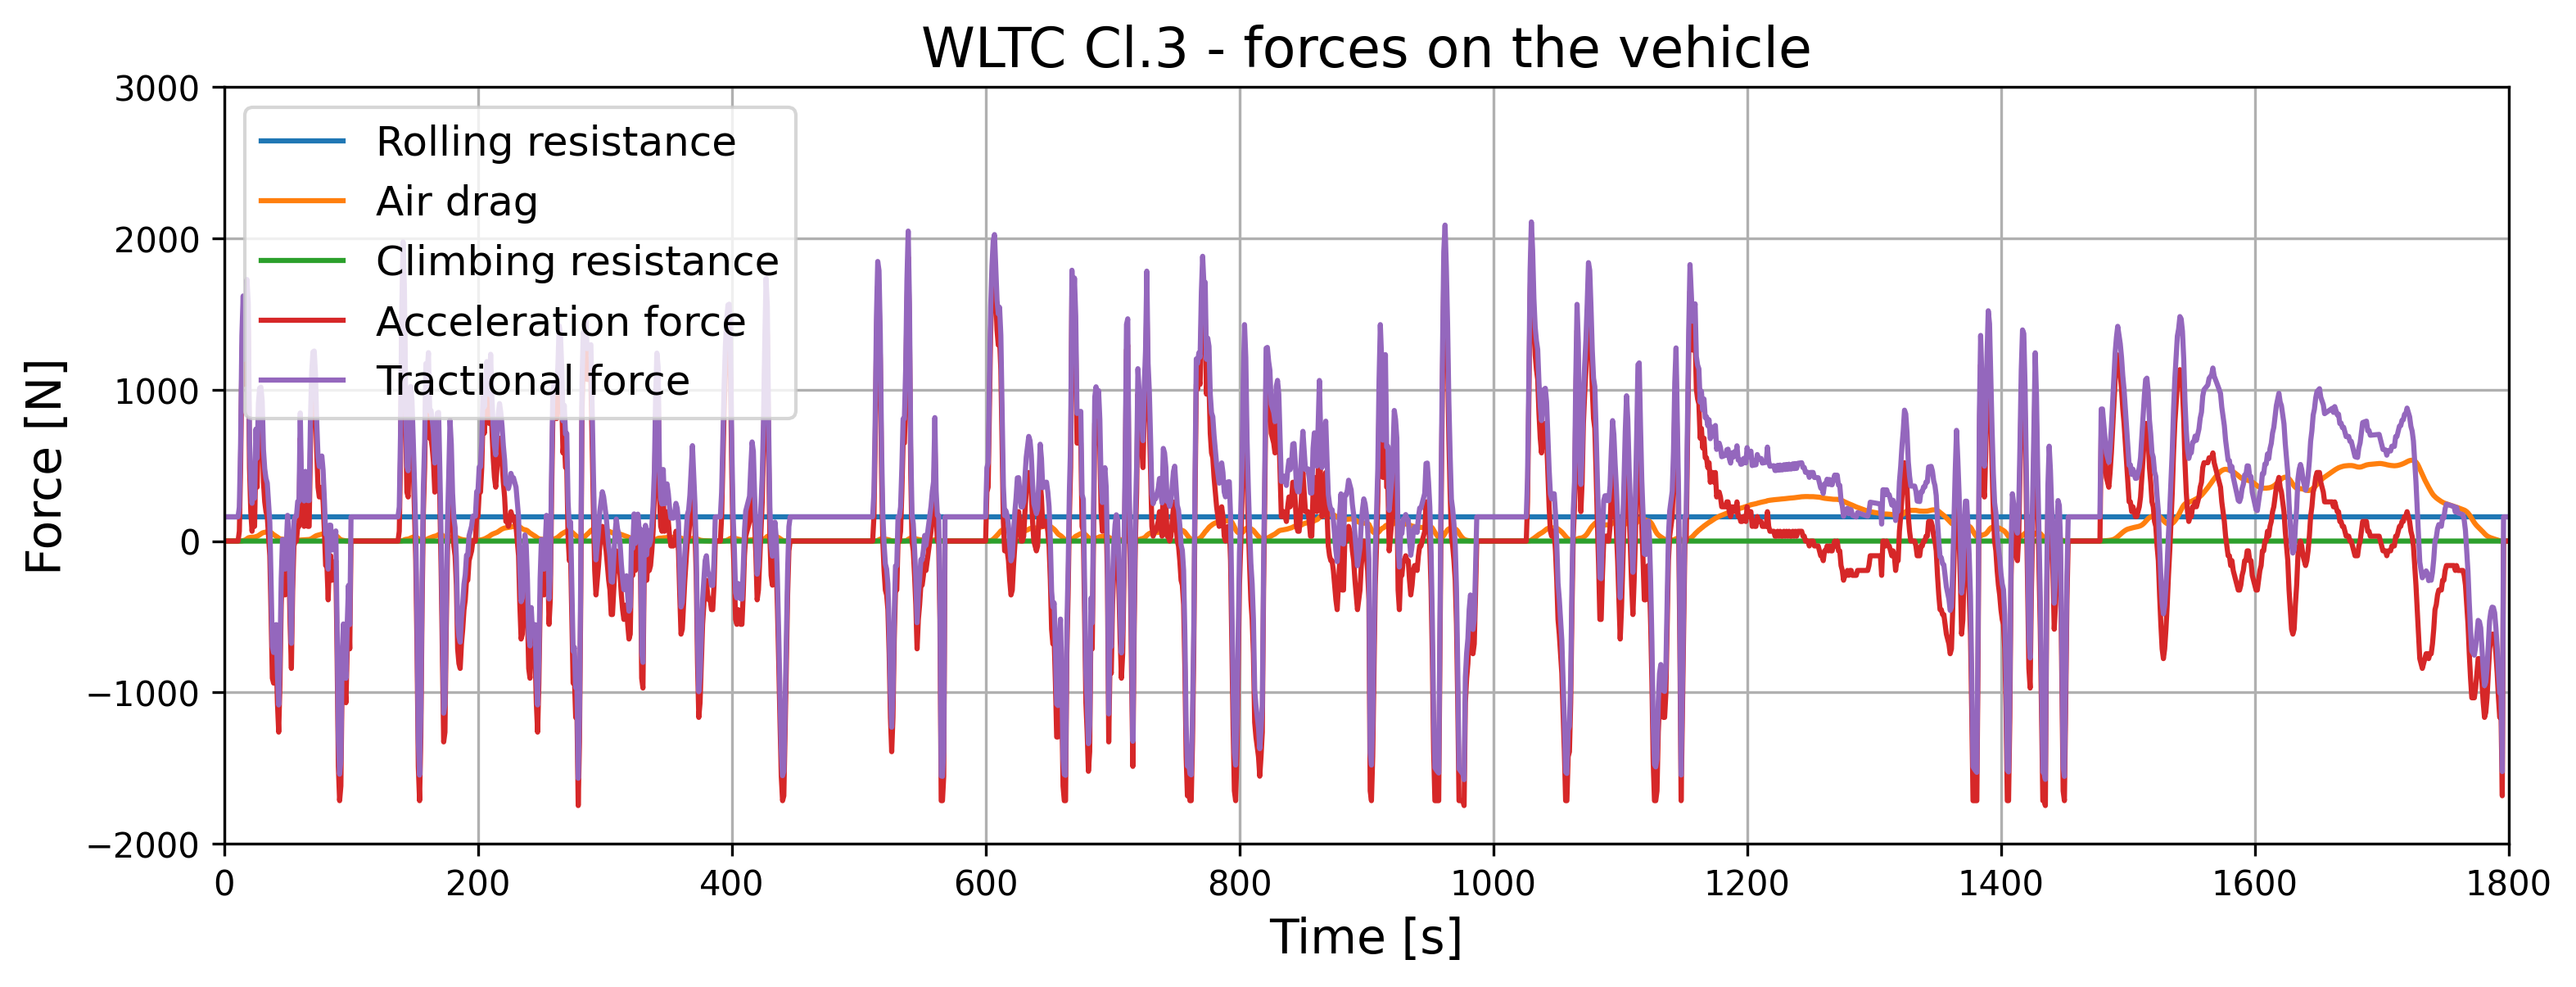

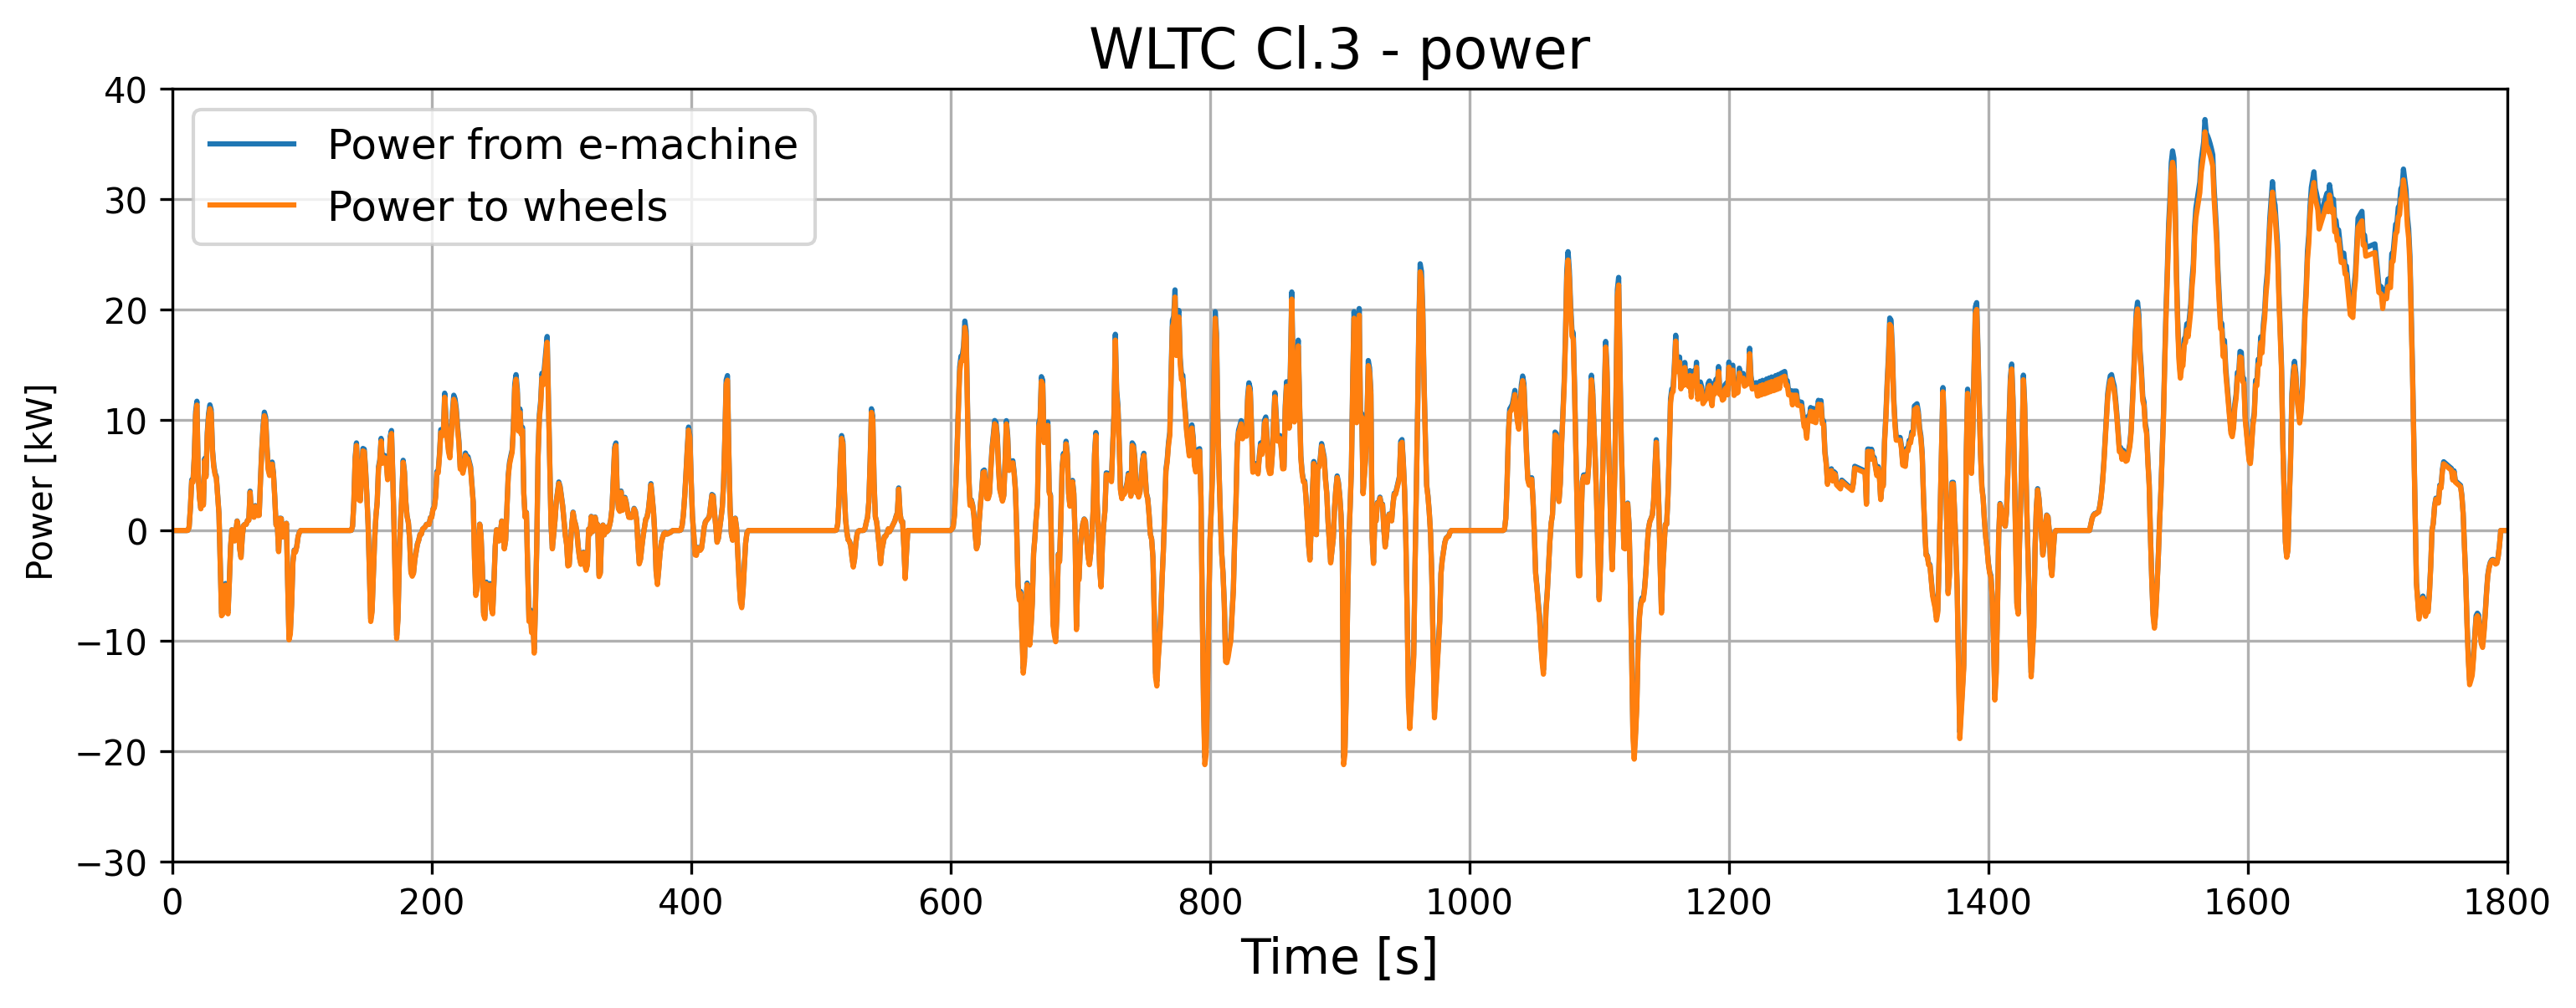

In [9]:
# %% Force calculation
DF_DC["F_roll"] = m_car * g * Cr * np.ones_like(DF_DC["t"])
DF_DC["F_drag"] = 0.5 * Cd * Af * DF_DC["v"]**2
DF_DC["F_climb"] = m_car * g * np.sin(DF_DC["alpha"])
DF_DC["F_acc"] = m_car * DF_DC["a"]
DF_DC["F_trac"] = DF_DC["F_roll"] + DF_DC["F_drag"] + DF_DC["F_climb"] + DF_DC["F_acc"]

plt.figure(figsize=size_plot, dpi=dpi_plot)
plt.plot( DF_DC["t"], DF_DC["F_roll"], label="Rolling resistance" )
plt.plot( DF_DC["t"], DF_DC["F_drag"], label="Air drag" )
plt.plot( DF_DC["t"], DF_DC["F_climb"], label="Climbing resistance" )
plt.plot( DF_DC["t"], DF_DC["F_acc"], label="Acceleration force" )
plt.plot( DF_DC["t"], DF_DC["F_trac"], label="Tractional force" )
plt.xlim( 0, max(DF_DC["t"]) )
plt.ylim(
    np.floor(min(DF_DC["F_trac"])/1000)*1000,
    np.ceil(max(DF_DC["F_trac"])/1000)*1000
    )
plt.grid()
plt.legend( fontsize=fz_legend )
plt.xlabel( "Time [s]", fontsize=fz_label )
plt.ylabel( "Force [N]", fontsize=fz_label )
plt.title( title_DC+" - forces on the vehicle", fontsize=fz_title )

DF_DC["P_wheel"] = DF_DC["F_trac"] * DF_DC["v"]
w_em = DF_DC["v"]/r_wheel * k_gear
DF_DC["n_em"] = w_em * 30 / np.pi
Trq_wheel = DF_DC["F_trac"] * r_wheel

idcs_gen = DF_DC["P_wheel"][DF_DC["P_wheel"] < 0].index
idcs_mot = DF_DC["P_wheel"][DF_DC["P_wheel"] >= 0].index

DF_DC["Trq_em"] = np.zeros_like(Trq_wheel)
DF_DC.loc[idcs_mot, "Trq_em"] = Trq_wheel[idcs_mot] / k_gear / eta_gear
DF_DC.loc[idcs_gen, "Trq_em"] = Trq_wheel[idcs_gen] / k_gear * eta_gear

DF_DC["P_em"] = w_em * DF_DC["Trq_em"]

plt.figure(figsize=size_plot, dpi=dpi_plot)
plt.plot( DF_DC["t"], DF_DC["P_em"] / 1000, label="Power from e-machine" )
plt.plot( DF_DC["t"], DF_DC["P_wheel"] / 1000, label="Power to wheels" )
plt.grid()
plt.xlim(0,max(DF_DC["t"]))
plt.ylim(
    np.floor(min(DF_DC["P_em"]/1000)/10)*10,
    np.ceil(max(DF_DC["P_em"]/1000)/10)*10
    )
plt.xlabel('Time [s]', fontsize=fz_label)
plt.ylabel('Power [kW] ')
plt.legend( fontsize=fz_legend )
plt.title(title_DC+" - power", fontsize=fz_title)

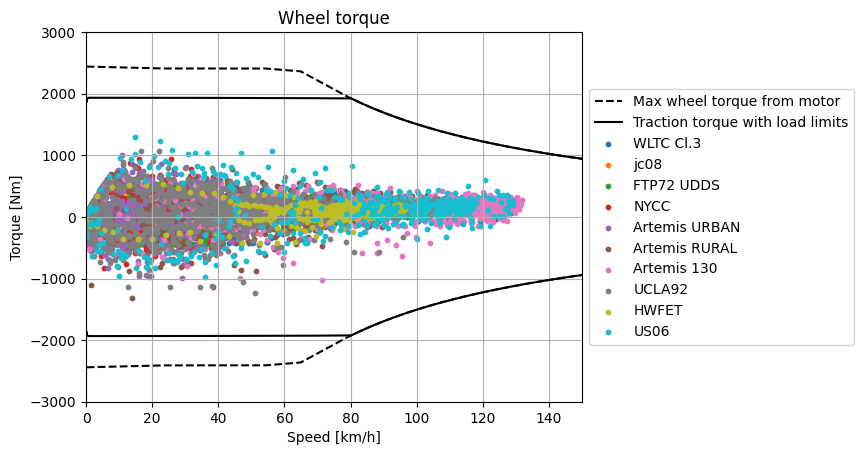

In [13]:
Trq_wheel_lim = np.ceil(DF_flat_150_s['Max wheel torque[Nm]'].max() * 1.1/500)*500
plt.figure()
plt.plot(DF_flat_150_s['Car speed[km/h]'], DF_flat_150_s['Max wheel torque[Nm]'], "--", color="black", label="Max wheel torque from motor")
plt.plot(DF_flat_150_s['Car speed[km/h]'], -DF_flat_150_s['Max wheel torque[Nm]'], "--", color="black")
plt.plot(DF_flat_150_s['Car speed[km/h]'], DF_flat_150_s['Traction torque[Nm]'], color="black", label="Traction torque with load limits")
plt.plot(DF_flat_150_s['Car speed[km/h]'], -DF_flat_150_s['Traction torque[Nm]'], color="black")
plt.xlim(0, 150)
plt.ylim(-Trq_wheel_lim, Trq_wheel_lim)
for filename_DC in list_DC_filename:
    DF_DC = pd.read_csv("drive_cycle/" + filename_DC + ".csv")
    title_DC = Dict_DC_name[filename_DC]
    DF_DC["F_roll"] = m_car * g * Cr * np.ones_like(DF_DC["t"])
    DF_DC["F_drag"] = 0.5 * Cd * Af * DF_DC["v"]**2
    DF_DC["F_climb"] = m_car * g * np.sin(DF_DC["alpha"])
    DF_DC["F_acc"] = m_car * DF_DC["a"]
    DF_DC["F_trac"] = DF_DC["F_roll"] + DF_DC["F_drag"] + DF_DC["F_climb"] + DF_DC["F_acc"]
    DF_DC["Trq_trac"] = DF_DC["F_trac"] * r_wheel
    plt.scatter(DF_DC["v"]*3.6, DF_DC["Trq_trac"], label=title_DC, s=10)    
plt.xlabel("Speed [km/h]")
plt.ylabel("Torque [Nm]")
plt.title("Wheel torque")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.show()